# Relationships
In this part we will explore how each feature correlate to each others.

---

## Import library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Load processed data

In [ ]:
df = pd.read_csv("../data/processed/rideshare_encoded.csv")
df.head()

,hour,day,month,source,destination,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,cab_type_Uber,short_summary_ Drizzle,short_summary_ Foggy,short_summary_ Light Rain,short_summary_ Mostly Cloudy,short_summary_ Overcast,short_summary_ Partly Cloudy,short_summary_ Possible Drizzle,short_summary_ Rain
0,9,16,12,5,7,7,5.0000,0.4400,1.0000,42.2148,-71.0330,42.3400,37.1200,0.0000,0.0000,0.6800,8.6600,9.1700,10.0000,43.6800,34.1900,37.9500,27.3900,32.7000,1021.9800,57,0.7200,0,303.8000,0.3000,0.1276,39.8900,43.6800,33.7300,38.0700,False,False,False,False,True,False,False,False,False
1,2,27,11,5,7,2,11.0000,0.4400,1.0000,42.2148,-71.0330,43.5800,37.3500,0.1299,1.0000,0.9400,11.9800,11.9800,4.7860,47.3000,42.1000,43.9200,36.2000,41.8300,1003.9700,90,1.0000,0,291.1000,0.6400,0.1300,40.4900,47.3000,36.2000,43.9200,False,False,False,False,False,False,False,False,True
2,1,28,11,5,7,5,7.0000,0.4400,1.0000,42.2148,-71.0330,38.3300,32.9300,0.0000,0.0000,0.7500,7.3300,7.3300,10.0000,47.5500,33.1000,44.1200,29.1100,31.1000,992.2800,240,0.0300,0,315.7000,0.6800,0.1064,35.3600,47.5500,31.0400,44.1200,False,False,False,False,False,False,False,False,False
3,4,30,11,5,7,4,26.0000,0.4400,1.0000,42.2148,-71.0330,34.3800,29.6300,0.0000,0.0000,0.7300,5.2800,5.2800,10.0000,45.0300,28.9000,38.5300,26.2000,26.6400,1013.7300,310,0.0000,0,291.1000,0.7500,0.0000,34.6700,45.0300,30.3000,38.5300,False,False,False,False,False,False,False,False,False
4,3,29,11,5,7,6,9.0000,0.4400,1.0000,42.2148,-71.0330,37.4400,30.8800,0.0000,0.0000,0.7000,9.1400,9.1400,10.0000,42.1800,36.7100,35.7500,30.2900,28.6100,998.3600,303,0.4400,0,347.7000,0.7200,0.0001,33.1000,42.1800,29.1100,35.7500,False,False,False,False,False,False,True,False,False


In [ ]:
df.shape

(637976, 37)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637976 entries, 0 to 637975
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   hour                     637976 non-null  int64  
 1   day                      637976 non-null  int64  
 2   month                    637976 non-null  int64  
 3   source                   637976 non-null  object 
 4   destination              637976 non-null  object 
 5   cab_type                 637976 non-null  object 
 6   name                     637976 non-null  object 
 7   price                    637976 non-null  float64
 8   distance                 637976 non-null  float64
 9   surge_multiplier         637976 non-null  float64
 10  latitude                 637976 non-null  float64
 11  longitude                637976 non-null  float64
 12  temperature              637976 non-null  float64
 13  apparentTemperature      637976 non-null  float64
 14  shor

In [ ]:
df.describe()

,hour,day,month,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
count,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000,637976.0000
mean,11.6185,17.7977,11.5866,16.5451,2.1893,1.0151,42.3382,-71.0661,39.5824,35.8784,0.0089,0.1459,0.7411,6.1868,8.4706,8.4692,45.0396,34.1489,41.6125,30.1380,31.6523,1010.0927,220.1127,0.6863,0.2490,313.5156,0.5791,0.0374,33.4562,45.2599,29.7290,41.9959
std,6.9488,9.9821,0.4925,9.3244,1.1354,0.0954,0.0479,0.0203,6.7255,7.9173,0.0269,0.3288,0.1386,3.1479,5.2887,2.6018,5.9960,6.3817,7.6652,8.0563,9.1414,13.4756,99.0872,0.3586,0.4743,27.9514,0.2447,0.0552,6.4663,5.6444,7.1099,6.9355
min,0.0000,1.0000,11.0000,2.5000,0.0200,1.0000,42.2148,-71.1054,18.9100,12.1300,0.0000,0.0000,0.3800,0.4500,0.8000,0.7170,32.6800,17.8500,22.6200,11.8100,4.3900,988.0900,2.0000,0.0000,0.0000,269.4000,0.0900,0.0000,15.6300,33.5100,11.8100,28.9500
25%,6.0000,13.0000,11.0000,9.0000,1.2700,1.0000,42.3503,-71.0810,36.4500,31.9100,0.0000,0.0000,0.6400,3.4100,4.0600,8.4320,42.5700,30.1700,36.5700,27.7000,27.4900,999.8200,124.0000,0.3700,0.0000,290.9000,0.3000,0.0000,30.1700,42.5700,27.7600,36.5700
50%,12.0000,17.0000,12.0000,13.5000,2.1600,1.0000,42.3519,-71.0631,40.4900,35.9000,0.0000,0.0000,0.7100,5.9100,7.5500,9.8800,44.6600,34.1800,40.9500,30.0300,30.6900,1009.2500,258.0000,0.8200,0.0000,307.4000,0.6800,0.0004,34.2400,44.6600,30.1300,40.9500
75%,18.0000,28.0000,12.0000,22.5000,2.9300,1.0000,42.3647,-71.0542,43.5800,40.0100,0.0000,0.0000,0.8800,8.4100,11.7400,9.9960,46.9100,38.7300,44.1200,35.3200,38.1200,1021.8600,303.0000,1.0000,0.0000,331.8000,0.7900,0.0916,38.8800,46.9100,35.7100,44.1200
max,23.0000,30.0000,12.0000,97.5000,7.8600,3.0000,42.3661,-71.0330,57.2200,57.2200,0.1447,1.0000,0.9600,15.0000,27.2500,10.0000,57.8700,46.6000,57.2000,47.2500,50.6700,1035.5500,356.0000,1.0000,2.0000,378.9000,0.9300,0.1459,43.1000,57.8700,40.0500,57.2000


In [ ]:
target = "price"

# columns that are actually category-like, even if encoded as numbers
categorical_like_cols = [
    "source", "destination", "name",
    "cab_type_Uber"
]

# one-hot weather summary columns
summary_cols = [col for col in df.columns if col.startswith("short_summary_")]

categorical_like_cols += summary_cols

# time/discrete columns
time_cols = ["hour", "day", "month"]

# continuous numeric columns
continuous_cols = [
    col for col in df.columns
    if col not in [target] + categorical_like_cols + time_cols
]

print("\nContinuous numeric columns:")
print(continuous_cols)

print("\nCategorical-like columns:")
print(categorical_like_cols)

print("\nTime/discrete columns:")
print(time_cols)



Continuous numeric columns:
['distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax']

Categorical-like columns:
['source', 'destination', 'name', 'cab_type_Uber', 'short_summary_ Drizzle ', 'short_summary_ Foggy ', 'short_summary_ Light Rain ', 'short_summary_ Mostly Cloudy ', 'short_summary_ Overcast ', 'short_summary_ Partly Cloudy ', 'short_summary_ Possible Drizzle ', 'short_summary_ Rain ']

Time/discrete columns:
['hour', 'day', 'month']


## Correlation Heatmap

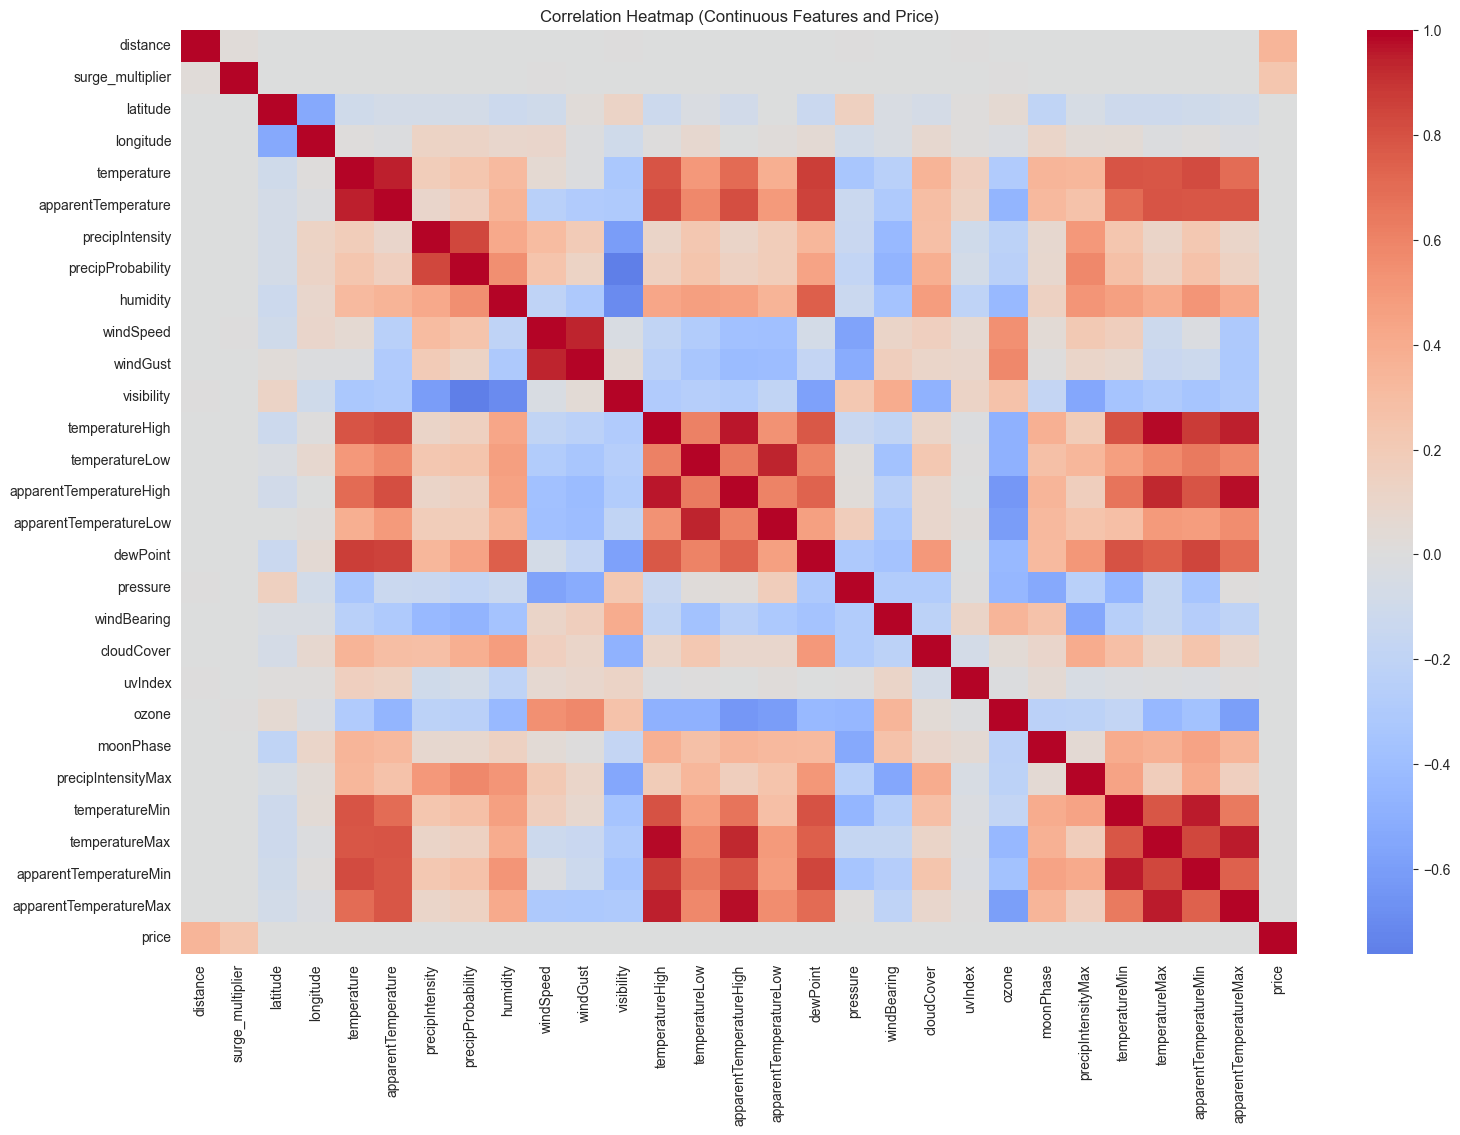

In [ ]:
corr_cols = continuous_cols + [target]
corr_matrix = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Continuous Features and Price)")
plt.show()

สิ่งพี่พบเจอคือจะเห็นว่า `distance` กับ `surge_multiplier` มีความสัมพันธ์ที่เกี่ยวข้องกับ `price` อย่างมีนัยสำคัญ นอกจากนี้จากกราฟจะเห็นว่า column ที่เป็นพวกสภาพอากาศจะมีความสัมพันธ์กันในระดับนึงอีกด้วยเช่นพวก `temperature`, `apparentTemperature`, `temperatureHigh`, `temperatureLow` เป็นต้น

## Correlation of continuous features with price

Correlation of continuous features with price:
distance                   0.3451
surge_multiplier           0.2405
latitude                   0.0021
moonPhase                 -0.0016
visibility                 0.0015
longitude                 -0.0014
windBearing               -0.0014
humidity                  -0.0012
windGust                   0.0012
precipIntensityMax         0.0011
windSpeed                  0.0010
cloudCover                 0.0009
pressure                   0.0009
apparentTemperatureLow     0.0008
dewPoint                  -0.0006
apparentTemperatureMin    -0.0006
temperatureMax            -0.0005
temperatureHigh           -0.0005
ozone                      0.0005
temperatureMin            -0.0004
uvIndex                   -0.0004
apparentTemperatureMax    -0.0003
apparentTemperatureHigh   -0.0003
precipProbability         -0.0002
apparentTemperature       -0.0002
temperatureLow             0.0002
precipIntensity            0.0002
temperature               -0.0001
N

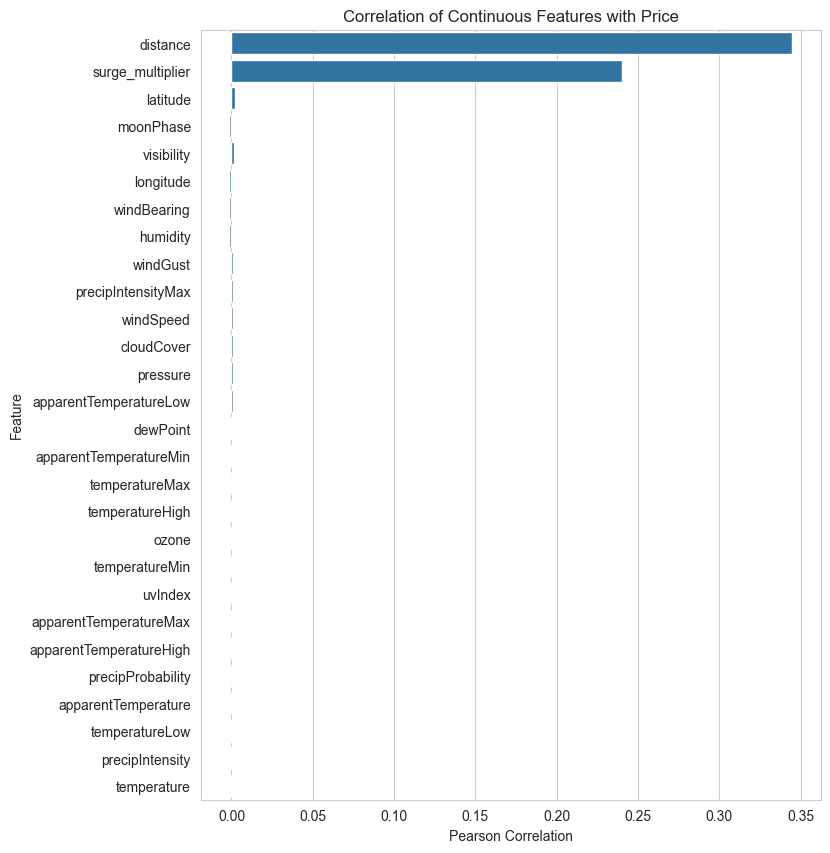

In [ ]:
price_corr = corr_matrix["price"].drop("price").sort_values(key=np.abs, ascending=False)

print("Correlation of continuous features with price:")
print(price_corr)

plt.figure(figsize=(8, 10))
sns.barplot(x=price_corr.values, y=price_corr.index)
plt.title("Correlation of Continuous Features with Price")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

จากค่า Pearson Correlation continuous features กับ `price` 
- `distance` มีความสัมพันธ์กับ price สูงที่สุดที่ 0.3451 ซึ่งอยู่ในระดับปานกลาง
- `surge_multiplier` มีความสัมพันธ์กับ price รองลงมาที่ 0.2405 ซึ่งจะอยู่ในระดับไม่เยอะมากแต่ก็มีผล
- ตัวแปร continuous อื่น ๆ ทั้งหมดมีค่า correlation น้อยมาก แสดงว่าแทบไม่มีความสัมพันธ์เลย
ดังนั้นปัจจัยที่สัมพันธ์กับ `price` จริง ๆ มีเด่น ๆ แค่ 2 ตัวคือ `distance` และ `surge_multiplier`

### Top continuous features vs price

In [ ]:
top_features = price_corr.head(4).index.tolist()

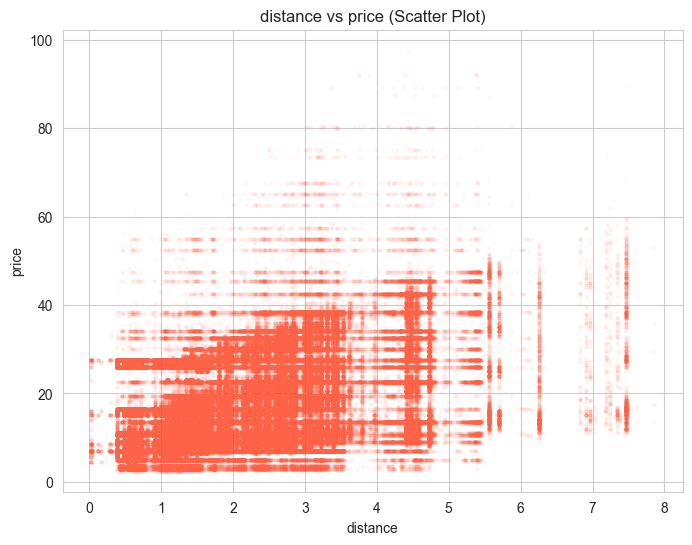

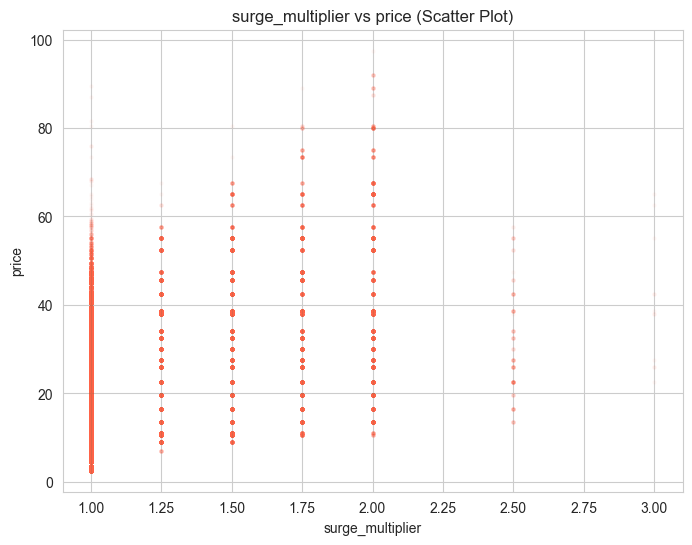

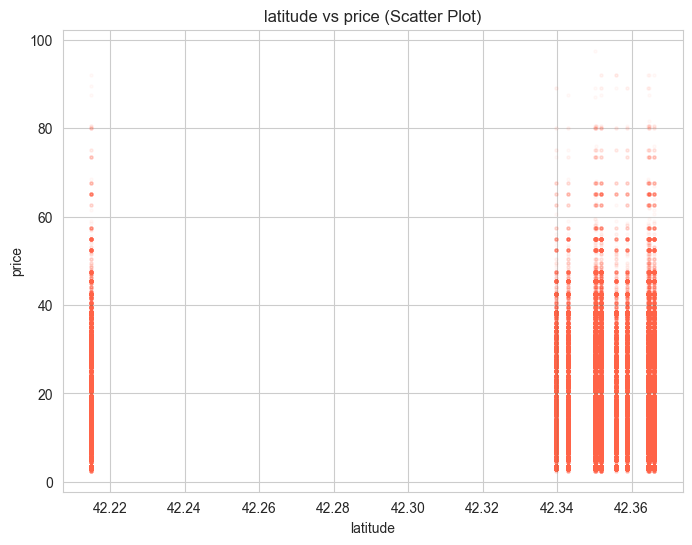

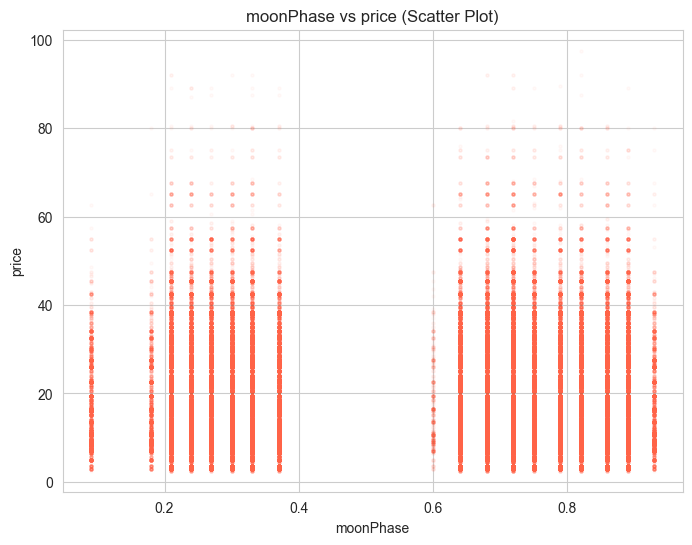

In [ ]:
for col in top_features:
    plt.figure(figsize=(8, 6))
    plt.scatter(df[col], df["price"], s=5, alpha=0.03, c="tomato")
    plt.xlabel(col)
    plt.ylabel("price")
    plt.title(f"{col} vs price (Scatter Plot)")
    plt.show()

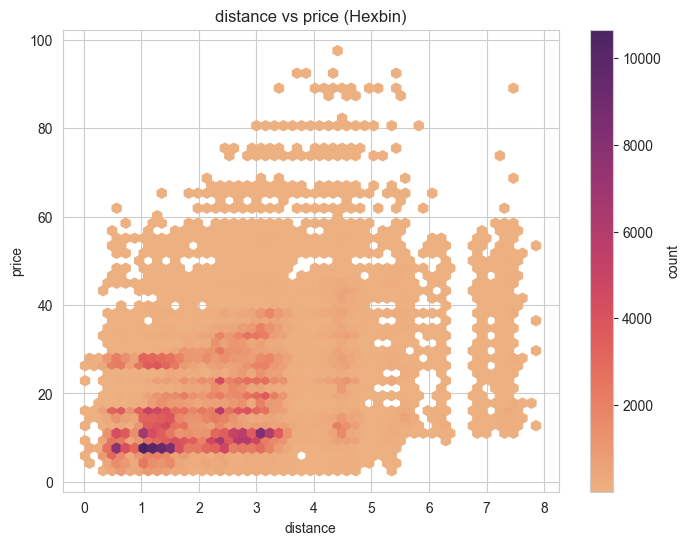

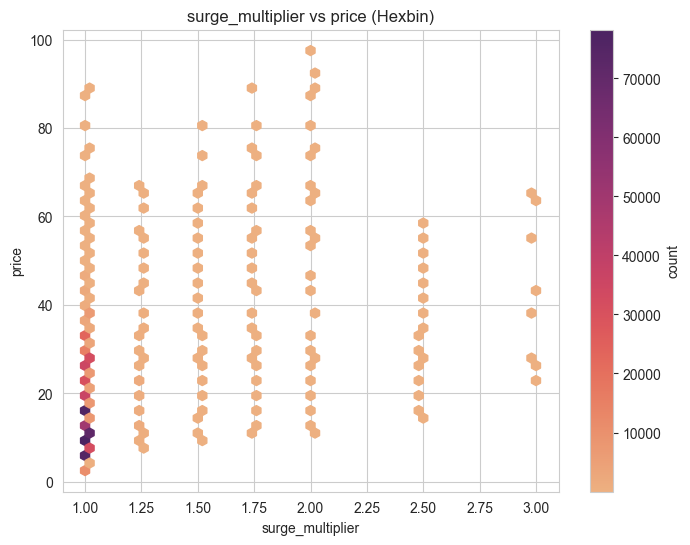

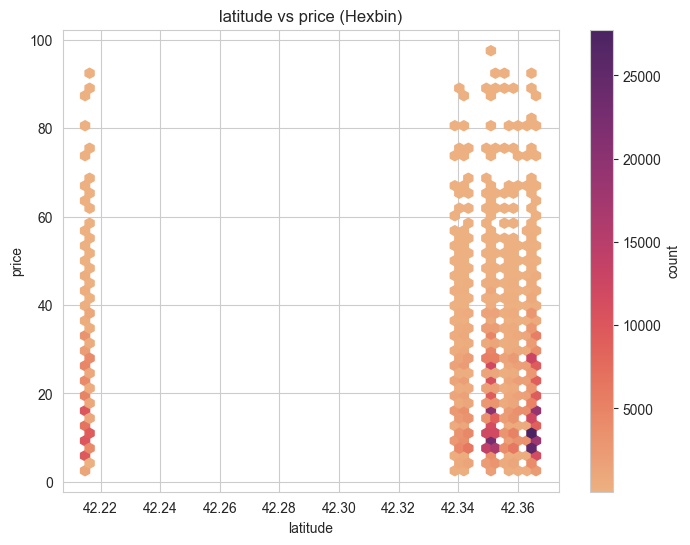

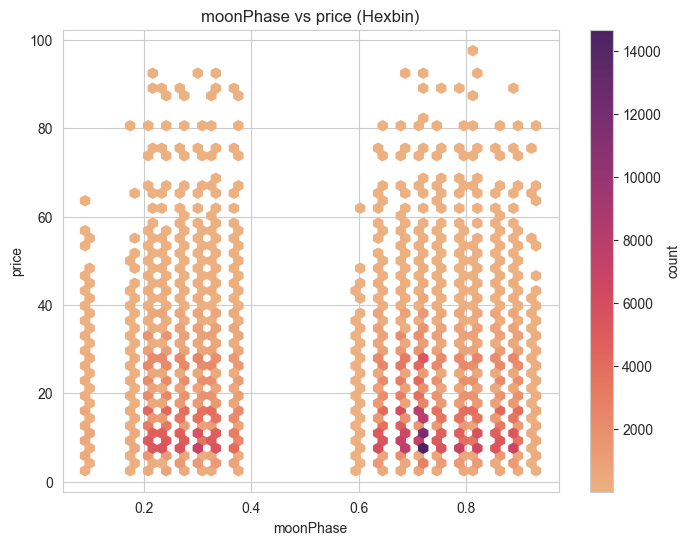

In [ ]:
for col in top_features:
    plt.figure(figsize=(8, 6))
    plt.hexbin(df[col], df["price"], gridsize=50, cmap="flare", mincnt=1)
    plt.colorbar(label="count")
    plt.xlabel(col)
    plt.ylabel("price")
    plt.title(f"{col} vs price (Hexbin)")
    plt.show()

จากกราฟยืนยันว่าใน continuous feature มีเพียง `distance` และ `surge_multiplier` เท่านั้นที่แสดงความสัมพันธ์กับ `price` อย่างมีนัยในการตีความ โดย `distance` มีแนวโน้มเชิงบวกกับราคา และ `surge_multiplier` ที่สูงขึ้นก็มักสัมพันธ์กับราคาที่สูงขึ้นเช่นกัน ขณะที่ `latitude` และ `moonPhase` ไม่แสดงรูปแบบที่ชัดเจน จึงไม่น่าจะเป็นตัวแปรสำคัญในการอธิบาย `price`

## Correlation of categorical features with price

In [ ]:
df_label = pd.read_csv("../data/processed/rideshare_cleaned.csv")
df_label.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0000,0.4400,1.0000,42.2148,-71.0330,42.3400,37.1200,Mostly Cloudy,0.0000,0.0000,0.6800,8.6600,9.1700,10.0000,43.6800,34.1900,37.9500,27.3900,32.7000,1021.9800,57,0.7200,0,303.8000,0.3000,0.1276,39.8900,43.6800,33.7300,38.0700
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0000,0.4400,1.0000,42.2148,-71.0330,43.5800,37.3500,Rain,0.1299,1.0000,0.9400,11.9800,11.9800,4.7860,47.3000,42.1000,43.9200,36.2000,41.8300,1003.9700,90,1.0000,0,291.1000,0.6400,0.1300,40.4900,47.3000,36.2000,43.9200
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0000,0.4400,1.0000,42.2148,-71.0330,38.3300,32.9300,Clear,0.0000,0.0000,0.7500,7.3300,7.3300,10.0000,47.5500,33.1000,44.1200,29.1100,31.1000,992.2800,240,0.0300,0,315.7000,0.6800,0.1064,35.3600,47.5500,31.0400,44.1200
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0000,0.4400,1.0000,42.2148,-71.0330,34.3800,29.6300,Clear,0.0000,0.0000,0.7300,5.2800,5.2800,10.0000,45.0300,28.9000,38.5300,26.2000,26.6400,1013.7300,310,0.0000,0,291.1000,0.7500,0.0000,34.6700,45.0300,30.3000,38.5300
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0000,0.4400,1.0000,42.2148,-71.0330,37.4400,30.8800,Partly Cloudy,0.0000,0.0000,0.7000,9.1400,9.1400,10.0000,42.1800,36.7100,35.7500,30.2900,28.6100,998.3600,303,0.4400,0,347.7000,0.7200,0.0001,33.1000,42.1800,29.1100,35.7500


In [ ]:
cat_features = ["name", "source", "destination", "cab_type_Uber"] # ไม่ใส่ binary one-hot

for col in cat_features:
    if col in df_label.columns:
        print(f"\nAverage price by {col}")
        print(df_label.groupby(col)["price"].mean().sort_values(ascending=False))


Average price by name
name
Lux Black XL   32.3241
Black SUV      30.2868
Lux Black      23.0625
Black          20.5238
Lux            17.7712
UberXL         15.6781
Lyft XL        15.3094
UberX           9.7651
WAV             9.7650
Lyft            9.6109
UberPool        8.7525
Shared          6.0299
Name: price, dtype: float64

Average price by source
source
Boston University         18.8530
Fenway                    18.3795
Financial District        18.1814
Northeastern University   17.9011
Theatre District          16.5970
North Station             16.3640
West End                  16.1085
Back Bay                  16.0474
South Station             15.6725
Beacon Hill               15.6640
North End                 15.1534
Haymarket Square          13.5781
Name: price, dtype: float64

Average price by destination
destination
Boston University         18.9421
Fenway                    18.1464
Financial District        18.0463
Northeastern University   17.8275
North Station         

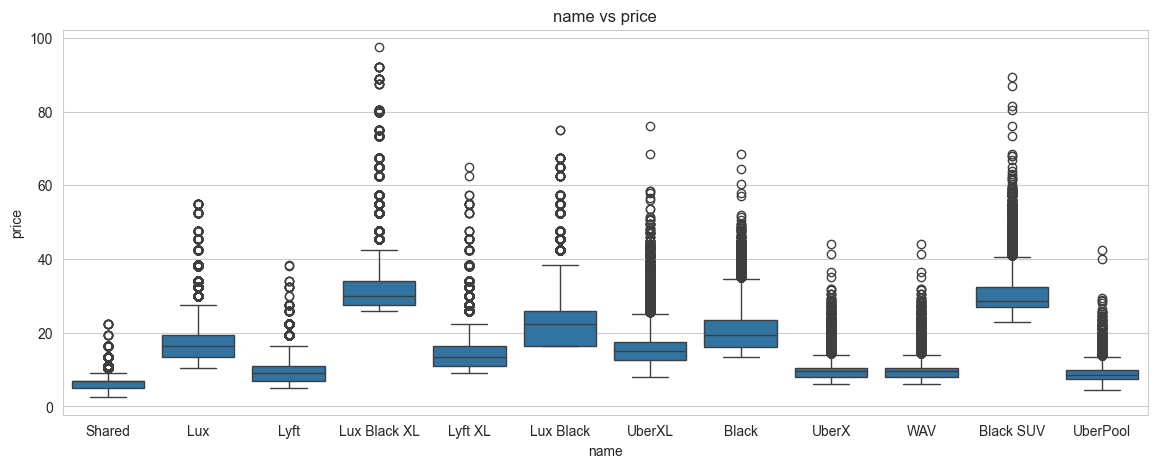

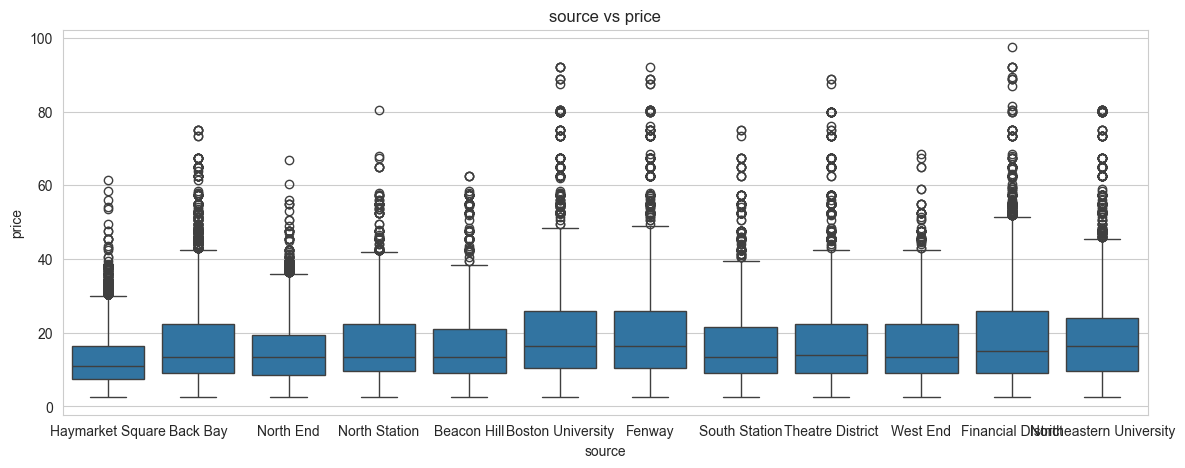

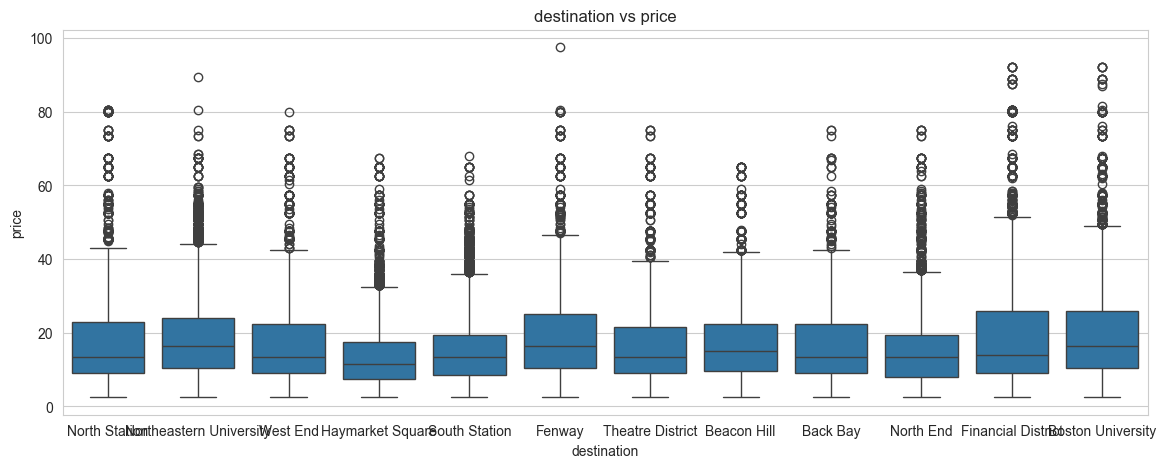

In [ ]:
for col in cat_features:
    if col in df_label.columns:
        plt.figure(figsize=(14, 5))
        sns.boxplot(data=df_label, x=col, y="price")
        plt.title(f"{col} vs price")
        plt.xlabel(col)
        plt.ylabel("price")
        plt.show()

จากกราฟ box plot เราจะเห็นว่าประเภทของรถหรือ `name` ส่งผลต่อราคาพอสมควร เนื่องจากการกระจุกตัวไม่เท่ากันในแต่ละประเภท ส่วน `source` and `destination` ไม่ผลบ้างแต่ไม่มากนักและ `cab_type_Uber` ที่เป็น boolean ก็แทบไม่เห็นความแตกต่างเลย

### Grouped Heatmap: source x destination vs average price

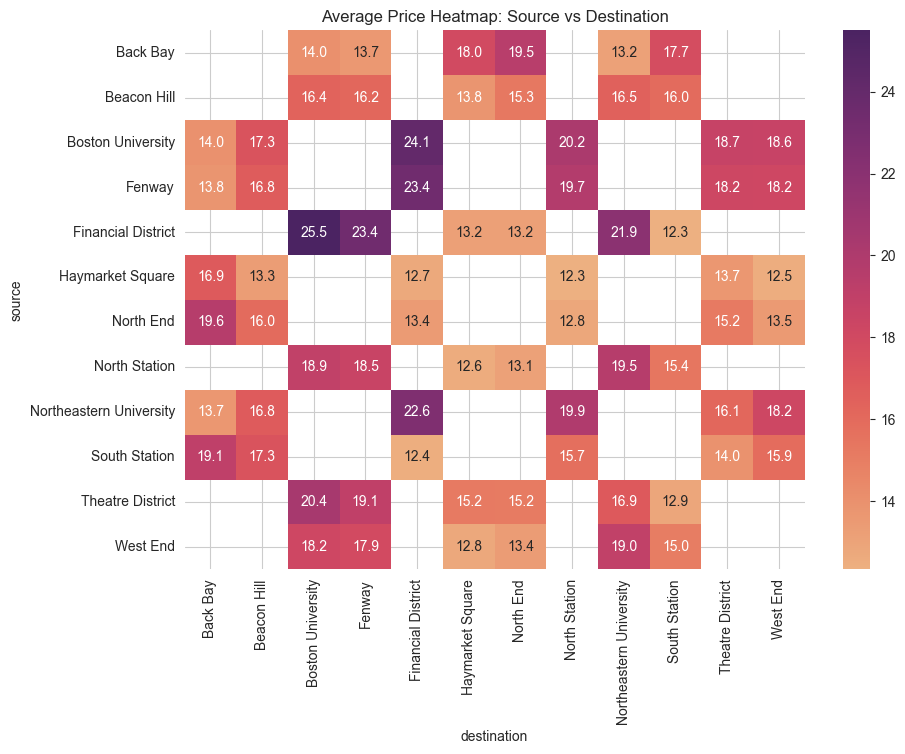

In [ ]:
route_price = df_label.pivot_table(
    index="source",
    columns="destination",
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(route_price, annot=True, fmt=".1f", cmap="flare")
plt.title("Average Price Heatmap: Source vs Destination")
plt.xlabel("destination")
plt.ylabel("source")
plt.show()

จาก heatmap ของราคาเฉลี่ยในแต่ละคู่ source และ destination พบว่าแต่ละจุดมีระดับราคาแตกต่างกัน โดยบางคู่มีราคาเฉลี่ยสูงกว่าคู่อื่นอย่างเด่นชัด เช่น คู่ที่เกี่ยวข้องกับ Financial District หลายคู่มีค่าเฉลี่ยสูงกว่าคู่อื่น แสดงว่า source และ destination ร่วมกันให้ข้อมูลเกี่ยวกับ price ได้ดีกว่าการวิเคราะห์แยกทีละตัวแปร

### Grouped Heatmap: source x destination vs average distance

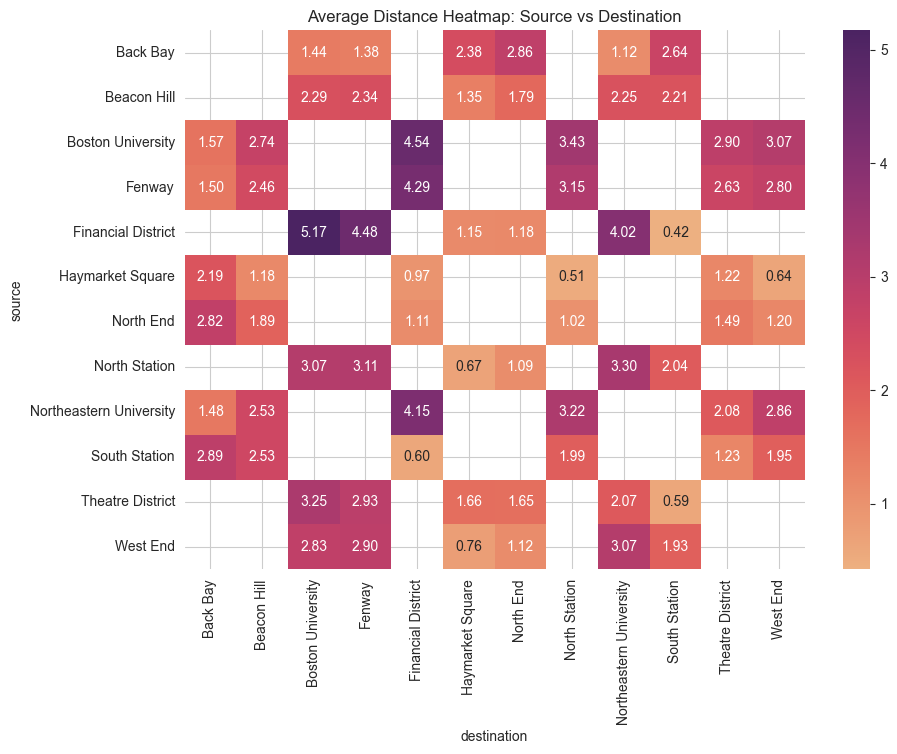

In [ ]:
route_distance = df_label.pivot_table(
    index="source",
    columns="destination",
    values="distance",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(route_distance, annot=True, fmt=".2f", cmap="flare")
plt.title("Average Distance Heatmap: Source vs Destination")
plt.xlabel("destination")
plt.ylabel("source")
plt.show()

In [ ]:
route_summary = df_label.groupby(["source", "destination"]).agg(
    avg_price=("price", "mean"),
    avg_distance=("distance", "mean"),
    trip_count=("price", "size")
).reset_index()

print(route_summary.sort_values("avg_price", ascending=False).head(20))

                     source              destination  avg_price  avg_distance  \
24       Financial District        Boston University    25.4984        5.1726   
14        Boston University       Financial District    24.1461        4.5440   
20                   Fenway       Financial District    23.4388        4.2901   
25       Financial District                   Fenway    23.4048        4.4778   
50  Northeastern University       Financial District    22.5821        4.1535   
28       Financial District  Northeastern University    21.9186        4.0208   
60         Theatre District        Boston University    20.3607        3.2530   
15        Boston University            North Station    20.1853        3.4314   
51  Northeastern University            North Station    19.9109        3.2227   
21                   Fenway            North Station    19.7018        3.1523   
36                North End                 Back Bay    19.5509        2.8197   
46            North Station 

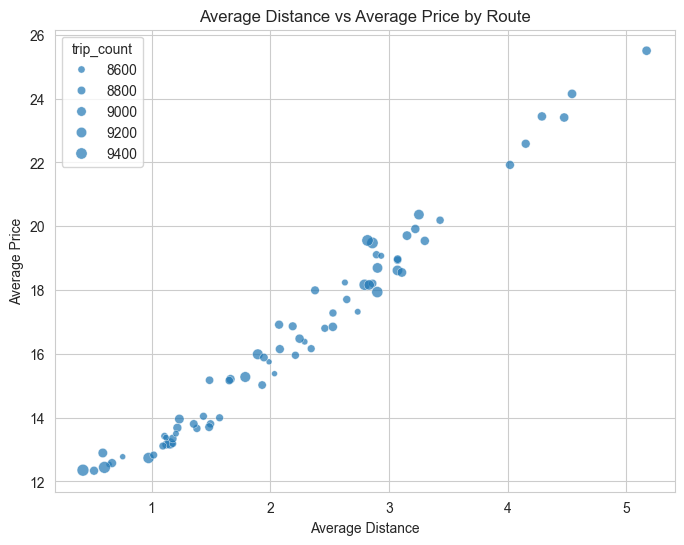

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=route_summary, x="avg_distance", y="avg_price", size="trip_count", alpha=0.7)
plt.title("Average Distance vs Average Price by Route")
plt.xlabel("Average Distance")
plt.ylabel("Average Price")
plt.show()

correlation แสดงความสัมพันธ์เป็นบวกนั่นคือ `distance` มากส่งผลให้ `price` มาก

## Time-based relation

In [ ]:
time_features = time_cols

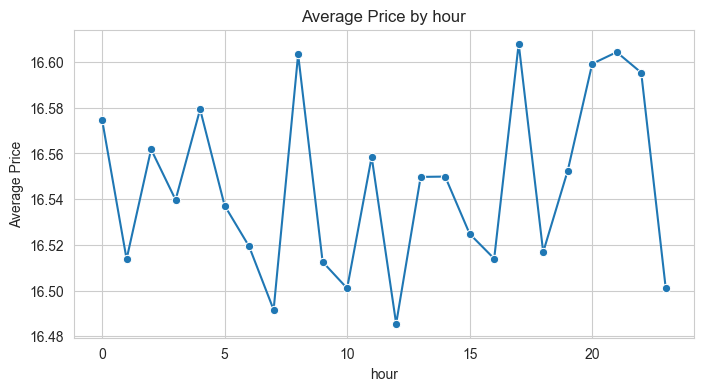

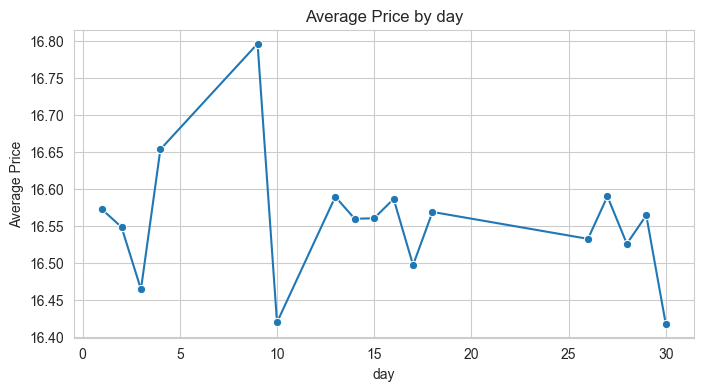

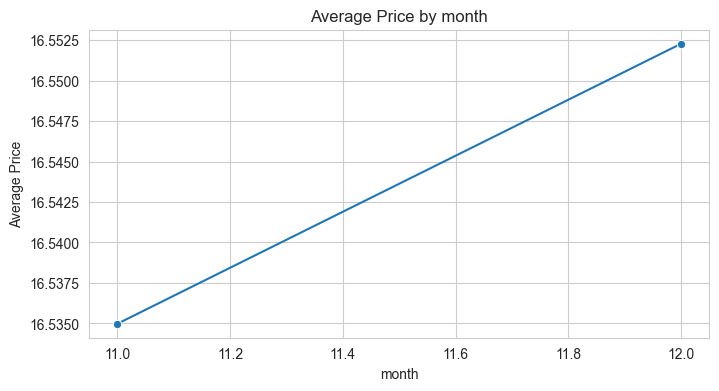

In [ ]:
for col in time_features:
    if col in df.columns:
        grouped = df.groupby(col)["price"].mean().reset_index()

        plt.figure(figsize=(8, 4))
        sns.lineplot(data=grouped, x=col, y="price", marker="o")
        plt.title(f"Average Price by {col}")
        plt.xlabel(col)
        plt.ylabel("Average Price")
        plt.show()

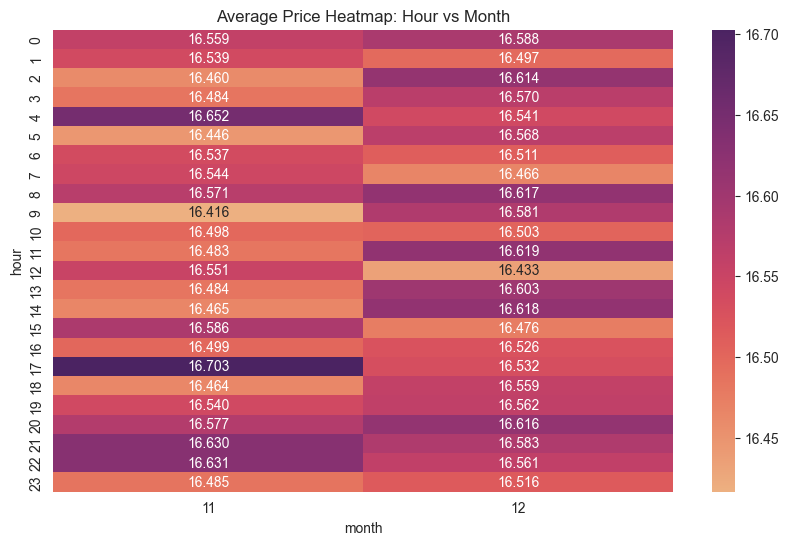

In [ ]:
hour_month_price = df.pivot_table(
    index="hour",
    columns="month",
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(hour_month_price, annot=True, fmt=".3f", cmap="flare")
plt.title("Average Price Heatmap: Hour vs Month")
plt.xlabel("month")
plt.ylabel("hour")
plt.show()

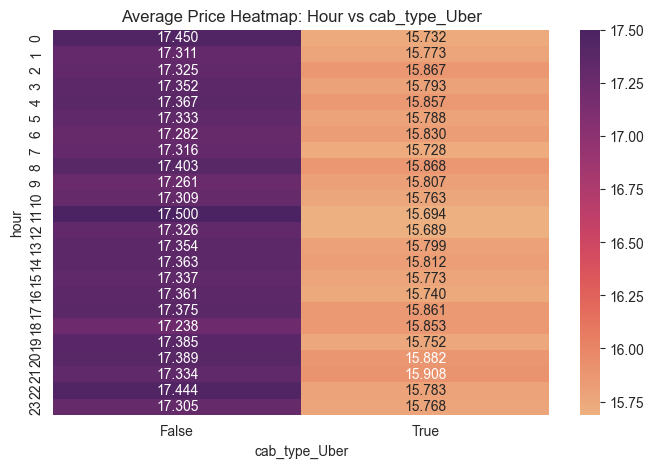

In [ ]:
hour_cab_price = df.pivot_table(
    index="hour",
    columns="cab_type_Uber",
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))
sns.heatmap(hour_cab_price, annot=True, fmt=".3f", cmap="flare")
plt.title("Average Price Heatmap: Hour vs cab_type_Uber")
plt.xlabel("cab_type_Uber")
plt.ylabel("hour")
plt.show()

จากกราฟ hour vs price, day vs price, month vs price กับ Hour x Month จะเห็นว่า hour กับ day ที่เป็นวันที่ไม่มีผลต่อราคาเลย และ month ที่มีแค่ 2 เดือนไม่สามารถระบุได้ว่ามี relation กับ price หรือไม่ แต่ กราฟสุุดท้าย Hour x cab_type_Uber เห็นได้ชัดเจนว่า Lift แพงกว่า Uber ในทุกชั่วโมงอย่างเห็นได้ชัด

## Key Findings
- distance และ surge_multiplier เป็น continuous features ที่สัมพันธ์กับ price ชัดที่สุด
- ในกลุ่ม categorical features ตัวแปร name แสดงความแตกต่างของราคาได้ชัดที่สุด
- คู่เส้นทาง source x destination มีผลต่อราคาเฉลี่ยอย่างชัดเจน
- อย่างไรก็ตาม ความต่างของราคาในแต่ละ route ไม่ได้อธิบายด้วย route เพียงอย่างเดียว เพราะภายใน route เดียวกันราคายังต่างกันมากตาม name
- ตัวแปรเวลา เช่น hour, day, และ month มีความสัมพันธ์กับราคาในระดับที่ต่ำ
- ความแตกต่างระหว่าง Uber และ Lift มีความสม่ำเสมอมากกว่าความต่างตามเวลาและเห็นได้ว่า Lift แพงกว่าอย่างเห็นได้ชัด